### Imports

In [43]:
import pickle
from copy import copy
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt

import re
from typing import List, Tuple, Generator

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.normalizers import Lowercase

from transformers import PreTrainedTokenizerFast

### Dataset loading

In [3]:
with open("data\\pos_data.txt", 'r', encoding = "utf-8") as f:
    data = list(filter(None, [line.rstrip("\n") for line in f]))

In [4]:
def merge_sentences(data: List[str]) -> List[List[Tuple[str, str]]]:
    """Merges sentences from the given list of lines"""
    sentences = []
    current_sentence = []
    for row in data:
        word_tag = re.search("\t.*?\t", row)[0].strip("\t")
        pos = re.search("[A-z]+", row)[0].strip("|") if word_tag not in ["<end>", "<beg>"] else re.search("\t.*?\t", row)[0].strip("\t")
        current_sentence.append((word_tag, pos))
        if current_sentence[0][0] == "<beg>" and current_sentence[-1][0] == "<end>":
            sentences.append(copy(current_sentence))
            current_sentence.clear()
        else:
            continue
    return sentences


In [5]:
processed_sentences = merge_sentences(data)
processed_sentences

[[('<beg>', '<beg>'),
  ('рой', 'VERB'),
  ('колодец', 'NOUN'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'), ('рой', 'VERB'), ('погреб', 'NOUN'), ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('рой', 'VERB'),
  ('укрытие', 'NOUN'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('я', 'PRON'),
  ('мою', 'VERB'),
  ('окно', 'NOUN'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('сотрудники', 'NOUN'),
  ('милиции', 'NOUN'),
  ('вечером', 'NOUN'),
  ('31', 'NUM'),
  ('декабря', 'NOUN'),
  ('уничтожили', 'VERB'),
  ('в', 'ADP'),
  ('хасавюрте', 'NOUN'),
  ('четверых', 'NUM'),
  ('боевиков', 'NOUN'),
  ('.', 'PUNCT'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('вместе', 'ADV'),
  ('с', 'ADP'),
  ('ним', 'PRON'),
  ('берлускони', 'NOUN'),
  ('выпустил', 'VERB'),
  ('уже', 'ADV'),
  ('четыре', 'NUM'),
  ('пластинки', 'NOUN'),
  ('.', 'PUNCT'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('психически', 'ADV'),
  ('неуравновешенный', 'ADJ'),
  ('житель', 'NOUN'),
  ('милана', 'NOUN'),
 

In [ ]:
# Saved processed dataset
# with open('artifacts\\pos_processed_dataset.pkl', 'wb') as file:
#     pickle.dump(processed_sentences, file)

In [7]:
# Load processed dataset
with open('artifacts\\pos_processed_dataset.pkl', 'rb') as file:
    processed_dataset = pickle.load(file)

In [8]:
processed_dataset

[[('<beg>', '<beg>'),
  ('рой', 'VERB'),
  ('колодец', 'NOUN'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'), ('рой', 'VERB'), ('погреб', 'NOUN'), ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('рой', 'VERB'),
  ('укрытие', 'NOUN'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('я', 'PRON'),
  ('мою', 'VERB'),
  ('окно', 'NOUN'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('сотрудники', 'NOUN'),
  ('милиции', 'NOUN'),
  ('вечером', 'NOUN'),
  ('31', 'NUM'),
  ('декабря', 'NOUN'),
  ('уничтожили', 'VERB'),
  ('в', 'ADP'),
  ('хасавюрте', 'NOUN'),
  ('четверых', 'NUM'),
  ('боевиков', 'NOUN'),
  ('.', 'PUNCT'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('вместе', 'ADV'),
  ('с', 'ADP'),
  ('ним', 'PRON'),
  ('берлускони', 'NOUN'),
  ('выпустил', 'VERB'),
  ('уже', 'ADV'),
  ('четыре', 'NUM'),
  ('пластинки', 'NOUN'),
  ('.', 'PUNCT'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('психически', 'ADV'),
  ('неуравновешенный', 'ADJ'),
  ('житель', 'NOUN'),
  ('милана', 'NOUN'),
 

In [9]:
words = [item[0] for sentence_list in processed_dataset for item in sentence_list]
print(len(words))
words

10251201


['<beg>',
 'рой',
 'колодец',
 '<end>',
 '<beg>',
 'рой',
 'погреб',
 '<end>',
 '<beg>',
 'рой',
 'укрытие',
 '<end>',
 '<beg>',
 'я',
 'мою',
 'окно',
 '<end>',
 '<beg>',
 'сотрудники',
 'милиции',
 'вечером',
 '31',
 'декабря',
 'уничтожили',
 'в',
 'хасавюрте',
 'четверых',
 'боевиков',
 '.',
 '<end>',
 '<beg>',
 'вместе',
 'с',
 'ним',
 'берлускони',
 'выпустил',
 'уже',
 'четыре',
 'пластинки',
 '.',
 '<end>',
 '<beg>',
 'психически',
 'неуравновешенный',
 'житель',
 'милана',
 'швырнул',
 'в',
 'политика',
 'тяжелую',
 'сувенирную',
 'статуэтку',
 '.',
 '<end>',
 '<beg>',
 'в',
 'марте',
 '2009',
 'года',
 'литва',
 'подписала',
 'десятилетний',
 'контракт',
 'на',
 'поставки',
 'электроэнергии',
 'из',
 'россии',
 '.',
 '<end>',
 '<beg>',
 'атмосферу',
 'на',
 'улицах',
 'сотрудники',
 'штаба',
 'охарактеризовали',
 'как',
 'праздничную',
 '.',
 '<end>',
 '<beg>',
 'бельгиец',
 'будет',
 'занимать',
 'пост',
 'президента',
 'ес',
 'два',
 'с',
 'половиной',
 'года',
 '.',
 '<end

In [10]:
words.extend(["<pad>", "<unk>"])

In [11]:
main_tags = set(item[1] for sentence_list in processed_dataset for item in sentence_list)
main_tags

{'harel',
 'fyi',
 'akira',
 'total',
 'lynx',
 'instruments',
 'store',
 'vii',
 'diastar',
 'descript',
 'boss',
 'team',
 'skrillex',
 'sw',
 'rom',
 'dinero',
 'harassment',
 'intelligere',
 'icq',
 'act',
 'amro',
 'kf',
 'ritchie',
 'vaiala',
 'assistance',
 'karateka',
 'balthus',
 'blues',
 'miptv',
 'prize',
 'were',
 'gti',
 'british',
 'podarcis',
 'galli',
 'jiburiru',
 'ofac',
 'jam',
 'tourismo',
 'isov',
 'hermann',
 'whisky',
 'writtingpad',
 'todorov',
 'bray',
 'compnews',
 'libre',
 'stainless',
 'durandus',
 'mathcad',
 'konica',
 'motosport',
 'annandale',
 'mulholland',
 'saving',
 'telltale',
 'penguin',
 'bordeaux',
 'odyssey',
 'punica',
 'onedrive',
 'allgemeine',
 'ustr',
 'nikelab',
 'read',
 'convention',
 'ritaru',
 'youth',
 'satura',
 'lightning',
 'bachelor',
 'del',
 'physiker',
 'beurteilen',
 'seiner',
 'haute',
 'transformation',
 'zeitschrift',
 'pliage',
 'joe',
 'strings',
 'wrong',
 'volariv',
 'cum',
 'asus',
 'unibos',
 'glencore',
 'comedy',


In [12]:
print(len(main_tags))

5206


In [13]:
# Create dict for class labels
key = 0
label_dict = dict()
for tag in main_tags:
    label_dict[tag] = key
    key += 1

In [15]:
label_dict["NOUN"]

2192

### Text tokenization

In [16]:
tokenizer = Tokenizer(model = BPE(unk_token = "<unk>"))
tokenizer.normalizer = Lowercase()

trainer = BpeTrainer(vocab_size = 30_000, special_tokens = ["<pad>", "<beg>", "<end>", "<unk>"])

In [19]:
tokenizer.train_from_iterator(iterator=words, trainer = trainer)

In [20]:
base_vocabulary = tokenizer.get_vocab()
base_vocabulary["<unk>"]
base_vocabulary

{'сырой': 21691,
 'являлись': 23727,
 'съезжа': 27460,
 'деньгами': 10236,
 'добром': 28693,
 'мето': 2484,
 'правым': 28151,
 'отрица': 4247,
 'гостиницу': 15890,
 'медицина': 24063,
 'психоте': 27453,
 'работал': 2927,
 'сделает': 9878,
 'мульти': 24470,
 'чера': 2476,
 'зды': 10297,
 'бру': 8568,
 'заворо': 17987,
 'категорически': 12939,
 'пожертво': 14268,
 'узкую': 27090,
 'ищи': 15610,
 'отступа': 7204,
 'перевя': 14294,
 'проехал': 29967,
 'заха': 15833,
 'стрельбу': 22241,
 'как говорится': 28675,
 'разбирается': 27537,
 'арбе': 12498,
 'бумаге': 16358,
 'запасы': 12385,
 'непри': 4899,
 'целой': 21465,
 'передали': 18611,
 'щения': 2019,
 'треть': 2331,
 'террито': 2442,
 'гне': 3589,
 'схема': 12480,
 'протер': 25447,
 'выжидал': 27154,
 'санкт-': 10870,
 'сток': 4487,
 'снимают': 25292,
 'киров': 15519,
 'выде': 17579,
 'входя': 17271,
 'обмен': 8688,
 'ine': 14421,
 'ступен': 15056,
 'отыскать': 13854,
 'оха': 26081,
 'автоном': 12646,
 'вско': 3401,
 'заведомо': 23845,
 '

In [21]:
# calculate maximum length of sentences
max_length = 0
for sentence in processed_dataset:
    max_length = max(max_length, len(sentence))
max_length

472

In [22]:
main_tokenizer = PreTrainedTokenizerFast(tokenizer_object = tokenizer, pad_token = "<pad>")

In [23]:
encoded_sentence = main_tokenizer("Хорошеесообщение", padding="max_length", max_length=max_length)["input_ids"]
encoded_sentence

[6761,
 7102,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0

In [24]:
main_tokenizer.decode(encoded_sentence, skip_special_tokens = True)

'хорошее сообщение'

In [25]:
# calculate maximum length of sentences
main_tokenizer

TokenizersBackend(name_or_path='', vocab_size=30000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'pad_token': '<pad>'}, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<beg>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<end>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

### Dataset preparation

In [26]:
processed_dataset

[[('<beg>', '<beg>'),
  ('рой', 'VERB'),
  ('колодец', 'NOUN'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'), ('рой', 'VERB'), ('погреб', 'NOUN'), ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('рой', 'VERB'),
  ('укрытие', 'NOUN'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('я', 'PRON'),
  ('мою', 'VERB'),
  ('окно', 'NOUN'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('сотрудники', 'NOUN'),
  ('милиции', 'NOUN'),
  ('вечером', 'NOUN'),
  ('31', 'NUM'),
  ('декабря', 'NOUN'),
  ('уничтожили', 'VERB'),
  ('в', 'ADP'),
  ('хасавюрте', 'NOUN'),
  ('четверых', 'NUM'),
  ('боевиков', 'NOUN'),
  ('.', 'PUNCT'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('вместе', 'ADV'),
  ('с', 'ADP'),
  ('ним', 'PRON'),
  ('берлускони', 'NOUN'),
  ('выпустил', 'VERB'),
  ('уже', 'ADV'),
  ('четыре', 'NUM'),
  ('пластинки', 'NOUN'),
  ('.', 'PUNCT'),
  ('<end>', '<end>')],
 [('<beg>', '<beg>'),
  ('психически', 'ADV'),
  ('неуравновешенный', 'ADJ'),
  ('житель', 'NOUN'),
  ('милана', 'NOUN'),
 

In [27]:
# Create generator for dataset
def dataset_generator(tokenizer = main_tokenizer):
        for sentence in processed_dataset:
            word_sentence = []
            targets = []
            for tup in sentence:
                word_sentence.append(tup[0])
                tokenized_word_length = len(tokenizer(tup[0])["input_ids"])
                if tokenized_word_length > 1:
                    for _ in range(tokenized_word_length):
                        targets.append(tup[1])
                else:
                    targets.append(tup[1])
            full_sentence = []
            for word in word_sentence:
                full_sentence.extend(tokenizer(word)["input_ids"])
            yield full_sentence, [label_dict[target] for target in targets]

In [35]:
processed_dataset_generator = dataset_generator()

Going through dataset:   0%|          | 6/990066 [03:04<8461:15:28, 30.77s/it]


In [36]:
for tokenized_sent, tokenized_tgt in tqdm(processed_dataset_generator, desc="Going through generator", total = 990066):
    assert len(tokenized_sent) == len(tokenized_tgt),  "Allignment problem"

Going through generator: 100%|██████████| 990066/990066 [07:57<00:00, 2073.23it/s]


### Model definition

In [28]:
len(main_tokenizer.get_vocab())

30000

In [30]:
class POSModel(nn.Module):
    def __init__(self, input_size:int, hidden_size:int,
                 num_embeddings:int = len(main_tokenizer.get_vocab()),
                 bidirectional: bool = False, vocab_size: int = len(main_tokenizer.get_vocab())):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, input_size)
        self.rnn = nn.LSTM(input_size, hidden_size, bidirectional = bidirectional)
        self.linear = nn.Linear(2*hidden_size, vocab_size)
        
    def forward(self, x):
        y = self.embedding(x)
        y = y.transpose(0, 1).squeeze(dim = 1)
        out, h = self.rnn(y) # S x B x H
        y = self.linear(out)
        return y

In [32]:
torch.cuda.is_available()

True

In [33]:
model = POSModel(input_size = 300, hidden_size = 300, num_embeddings=30_000, bidirectional = True)
model.to(device = 'cuda')

POSModel(
  (embedding): Embedding(30000, 300)
  (rnn): LSTM(300, 300, bidirectional=True)
  (linear): Linear(in_features=600, out_features=30000, bias=True)
)

### Training

In [36]:
# 5 samples training dataset
training_samples = []
for data in dataset_generator():
    if len(training_samples) < 5:
        training_samples.append(data)
    else:
        break

In [50]:
epoch = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.005, betas = (0.98,0.99))

In [54]:
def train_model(dataset, model, device = 'cuda'):
    epoch_losses = []
    for ep in tqdm(range(epoch)):
        current_epoch_loss = []
        for data, tgt in dataset:
            data, tgt = torch.tensor(data).reshape(1, -1).to(device=device), torch.tensor(tgt).to(device=device)
            optimizer.zero_grad()
            prediction = model(data)
            loss = criterion(prediction, tgt)
            loss.backward()
            optimizer.step()
            current_epoch_loss.append(loss.item())
        avg_loss = np.array(current_epoch_loss).mean()
        epoch_losses.append(avg_loss)
        torch.save(model.state_dict(), f=f"artifacts\\epoch#{ep + 1}_modelWeights.pth")
        torch.save(optimizer.state_dict(), f=f"artifacts\\epoch#{ep + 1}_optimizerWeights.pth")
        print(f"Epoch #{ep + 1} | Current loss: {avg_loss}")
    return epoch_losses

In [55]:
result = train_model(dataset_generator(), model)

 10%|█         | 1/10 [5:25:08<48:46:15, 19508.40s/it]

Epoch #1 | Current loss: 0.27098823125490995


C:\Users\luchi\AppData\Local\Temp\ipykernel_12068\3500191893.py:13: RuntimeWarning: Mean of empty slice
  avg_loss = np.array(current_epoch_loss).mean()
d:\main\nlpTasks\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
 20%|██        | 2/10 [5:25:10<17:51:11, 8033.95s/it] 

Epoch #2 | Current loss: nan


 30%|███       | 3/10 [5:25:12<8:29:24, 4366.33s/it] 

...

Epoch #8 | Current loss: nan


 90%|█████████ | 9/10 [5:25:27<05:53, 353.97s/it]

Epoch #9 | Current loss: nan


100%|██████████| 10/10 [5:25:30<00:00, 1953.02s/it]

Epoch #10 | Current loss: nan


In [57]:
optimizer.load_state_dict(torch.load(f"artifacts\\epoch#1_optimizerWeights.pth"))

In [58]:
model

POSModel(
  (embedding): Embedding(30000, 300)
  (rnn): LSTM(300, 300, bidirectional=True)
  (linear): Linear(in_features=600, out_features=30000, bias=True)
)

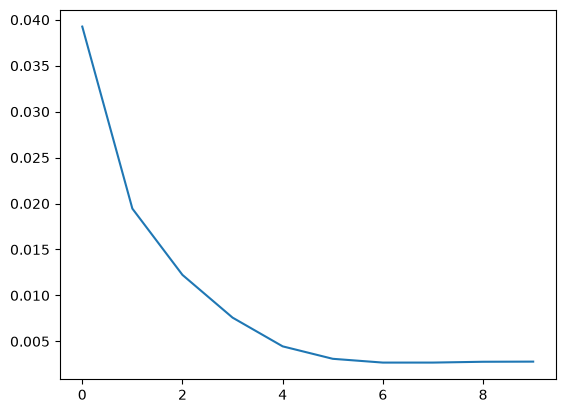

In [47]:
plt.plot(result)

### Inference

In [59]:
main_tokenizer

TokenizersBackend(name_or_path='', vocab_size=30000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'pad_token': '<pad>'}, added_tokens_decoder={
	0: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<beg>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("<end>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [86]:
def inference(text:str, model:nn.Module = model, tokenizer:PreTrainedTokenizerFast = main_tokenizer):
    tokenized_text = main_tokenizer(text)["input_ids"]
    tokens_tags = []
    for token in tokenized_text:
        prediction = model(torch.tensor([[token]]).to(device="cuda"))
        tag = prediction.softmax(dim = 1).argmax(dim = 1).item()
        tag_word = None
        for key in label_dict:
            if label_dict[key] == tag:
                tag_word = key
        word_word = main_tokenizer.decode([token])
        tokens_tags.append((word_word, tag_word))
    return tokens_tags

In [90]:
result = inference("Он пошел гулять")
result

[('он', 'PRON'),
 (' ', 'ADV'),
 ('пошел', 'VERB'),
 (' ', 'ADV'),
 ('гулять', 'VERB')]